In [2]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse

from pathlib import Path

from graph_transformer_long_range_niches.pp import sliding_window, split_adata
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS

In [3]:
LEGNINI23 = "/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad"

# Load data

Figure 3.f,h

In [4]:
adata = sc.read_h5ad(LEGNINI23)
adata

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    obsm: 'spatial'

In [5]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [4]:
# adata.obsm['spatial'] = adata.obsm['coordinates']
# del adata.obsm['coordinates']

In [5]:
# np.isnan(adata.obsm["spatial"]).sum()

Remove all cells that have entry NaN in .obsm['coordinates'].
If NaN is in .obsm it leads to error when creating graph. 

In [11]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

NaN values remaining: 0


Make sure that obs_names are unique and convertable to string. 

In [20]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    uns: 'condition_colors'
    obsm: 'spatial'>

In [21]:
adata.obs['obs_names'] = adata.obs_names

In [22]:
adata.obs_names = np.array(range(adata.n_obs))

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/_core/anndata.py:841: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")


In [64]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '43752', '43753', '43754', '43755', '43756', '43757', '43758', '43759',
       '43760', '43761'],
      dtype='object', length=43762)

In [41]:
adata.write(LEGNINI23)

In [44]:
adata.obs_names = adata.obs_names.str.replace('-', '', regex=False)

In [39]:
adata.obs_names

Index(['A2-1_c1', 'A2-1_c10', 'A2-1_c100', 'A2-1_c1000', 'A2-1_c1001',
       'A2-1_c1002', 'A2-1_c1003', 'A2-1_c1004', 'A2-1_c1005', 'A2-1_c1006',
       ...
       'W5A3_c990', 'W5A3_c991', 'W5A3_c992', 'W5A3_c993', 'W5A3_c994',
       'W5A3_c995', 'W5A3_c996', 'W5A3_c997', 'W5A3_c998', 'W5A3_c999'],
      dtype='object', length=43762)

In [20]:
shh_slides = ['slide4_A2-1', 'slide4_B2-2']

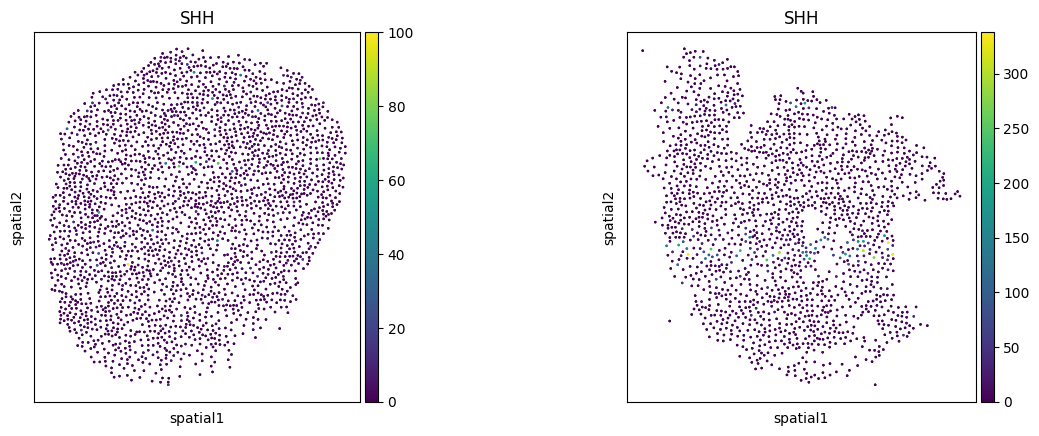

In [23]:
sq.pl.spatial_scatter(
        adata,
        library_key = 'sample',
        library_id = shh_slides,
        color = ['SHH'],
        shape= None,
)

In [23]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['sample', 'condition', 'organoid']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

sample       condition  organoid   
slide1_D2-2  SHH        organoid #2    4318
slide1_D2-3  SHH        organoid #4    3621
slide1_C2-2  SHH        organoid #2    3510
slide4_B2-1  SHH        organoid #2    3345
slide1_B2-1  SHH        organoid #2    3299
slide1_A2-1  SHH        organoid #2    3023
slide1_C2-1  Ctrl       organoid #5    2870
slide4_A2-1  SHH        organoid #2    2630
slide4_A2-2  SHH        organoid #1    2506
slide1_B2-3  SHH        organoid #4    2241
slide4_A2-3  Ctrl       organoid #5    1984
slide1_C2-5  Ctrl       organoid #8    1958
slide4_B2-2  SHH        organoid #3    1779
slide1_B2-2  Ctrl       organoid #6    1701
slide1_A2-2  SHH        organoid #4    1694
slide4_B2-3  Ctrl       organoid #7    1643
slide1_C2-3  Ctrl       organoid #7    1640
Name: count, dtype: int64


In [24]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    uns: 'condition_colors'
    obsm: 'spatial'

## SHH pathway genes

According to publication the induction was best achieved in: in organoids 2 and 3 (e.g. slide 4 A2-1 and slide 4 B2-2 are shown in the associated publication).

In [12]:
pathway_genes = ['FOXA2', 'FOXG1', 'NKX2.1', 'NKX6.2', 'OLIG2']
upregulated_genes = ['FOXA1', 'FOXA2']
downregulated_genes = ['DBX2', 'DBX1']

In [13]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    obsm: 'spatial'
    layers: 'raw', 'log1p_norm'

In [54]:
# sq.pl.spatial_scatter(
#     adata,
#     library_key = 'sample',
#     #library_id = ['slide1_A2-1', 'slide4_B2-2'],
#     color =  ['NKX2.1', 'TBR1', 'NKX6.2'],
#     shape= None,
#     size = 8, 
# )

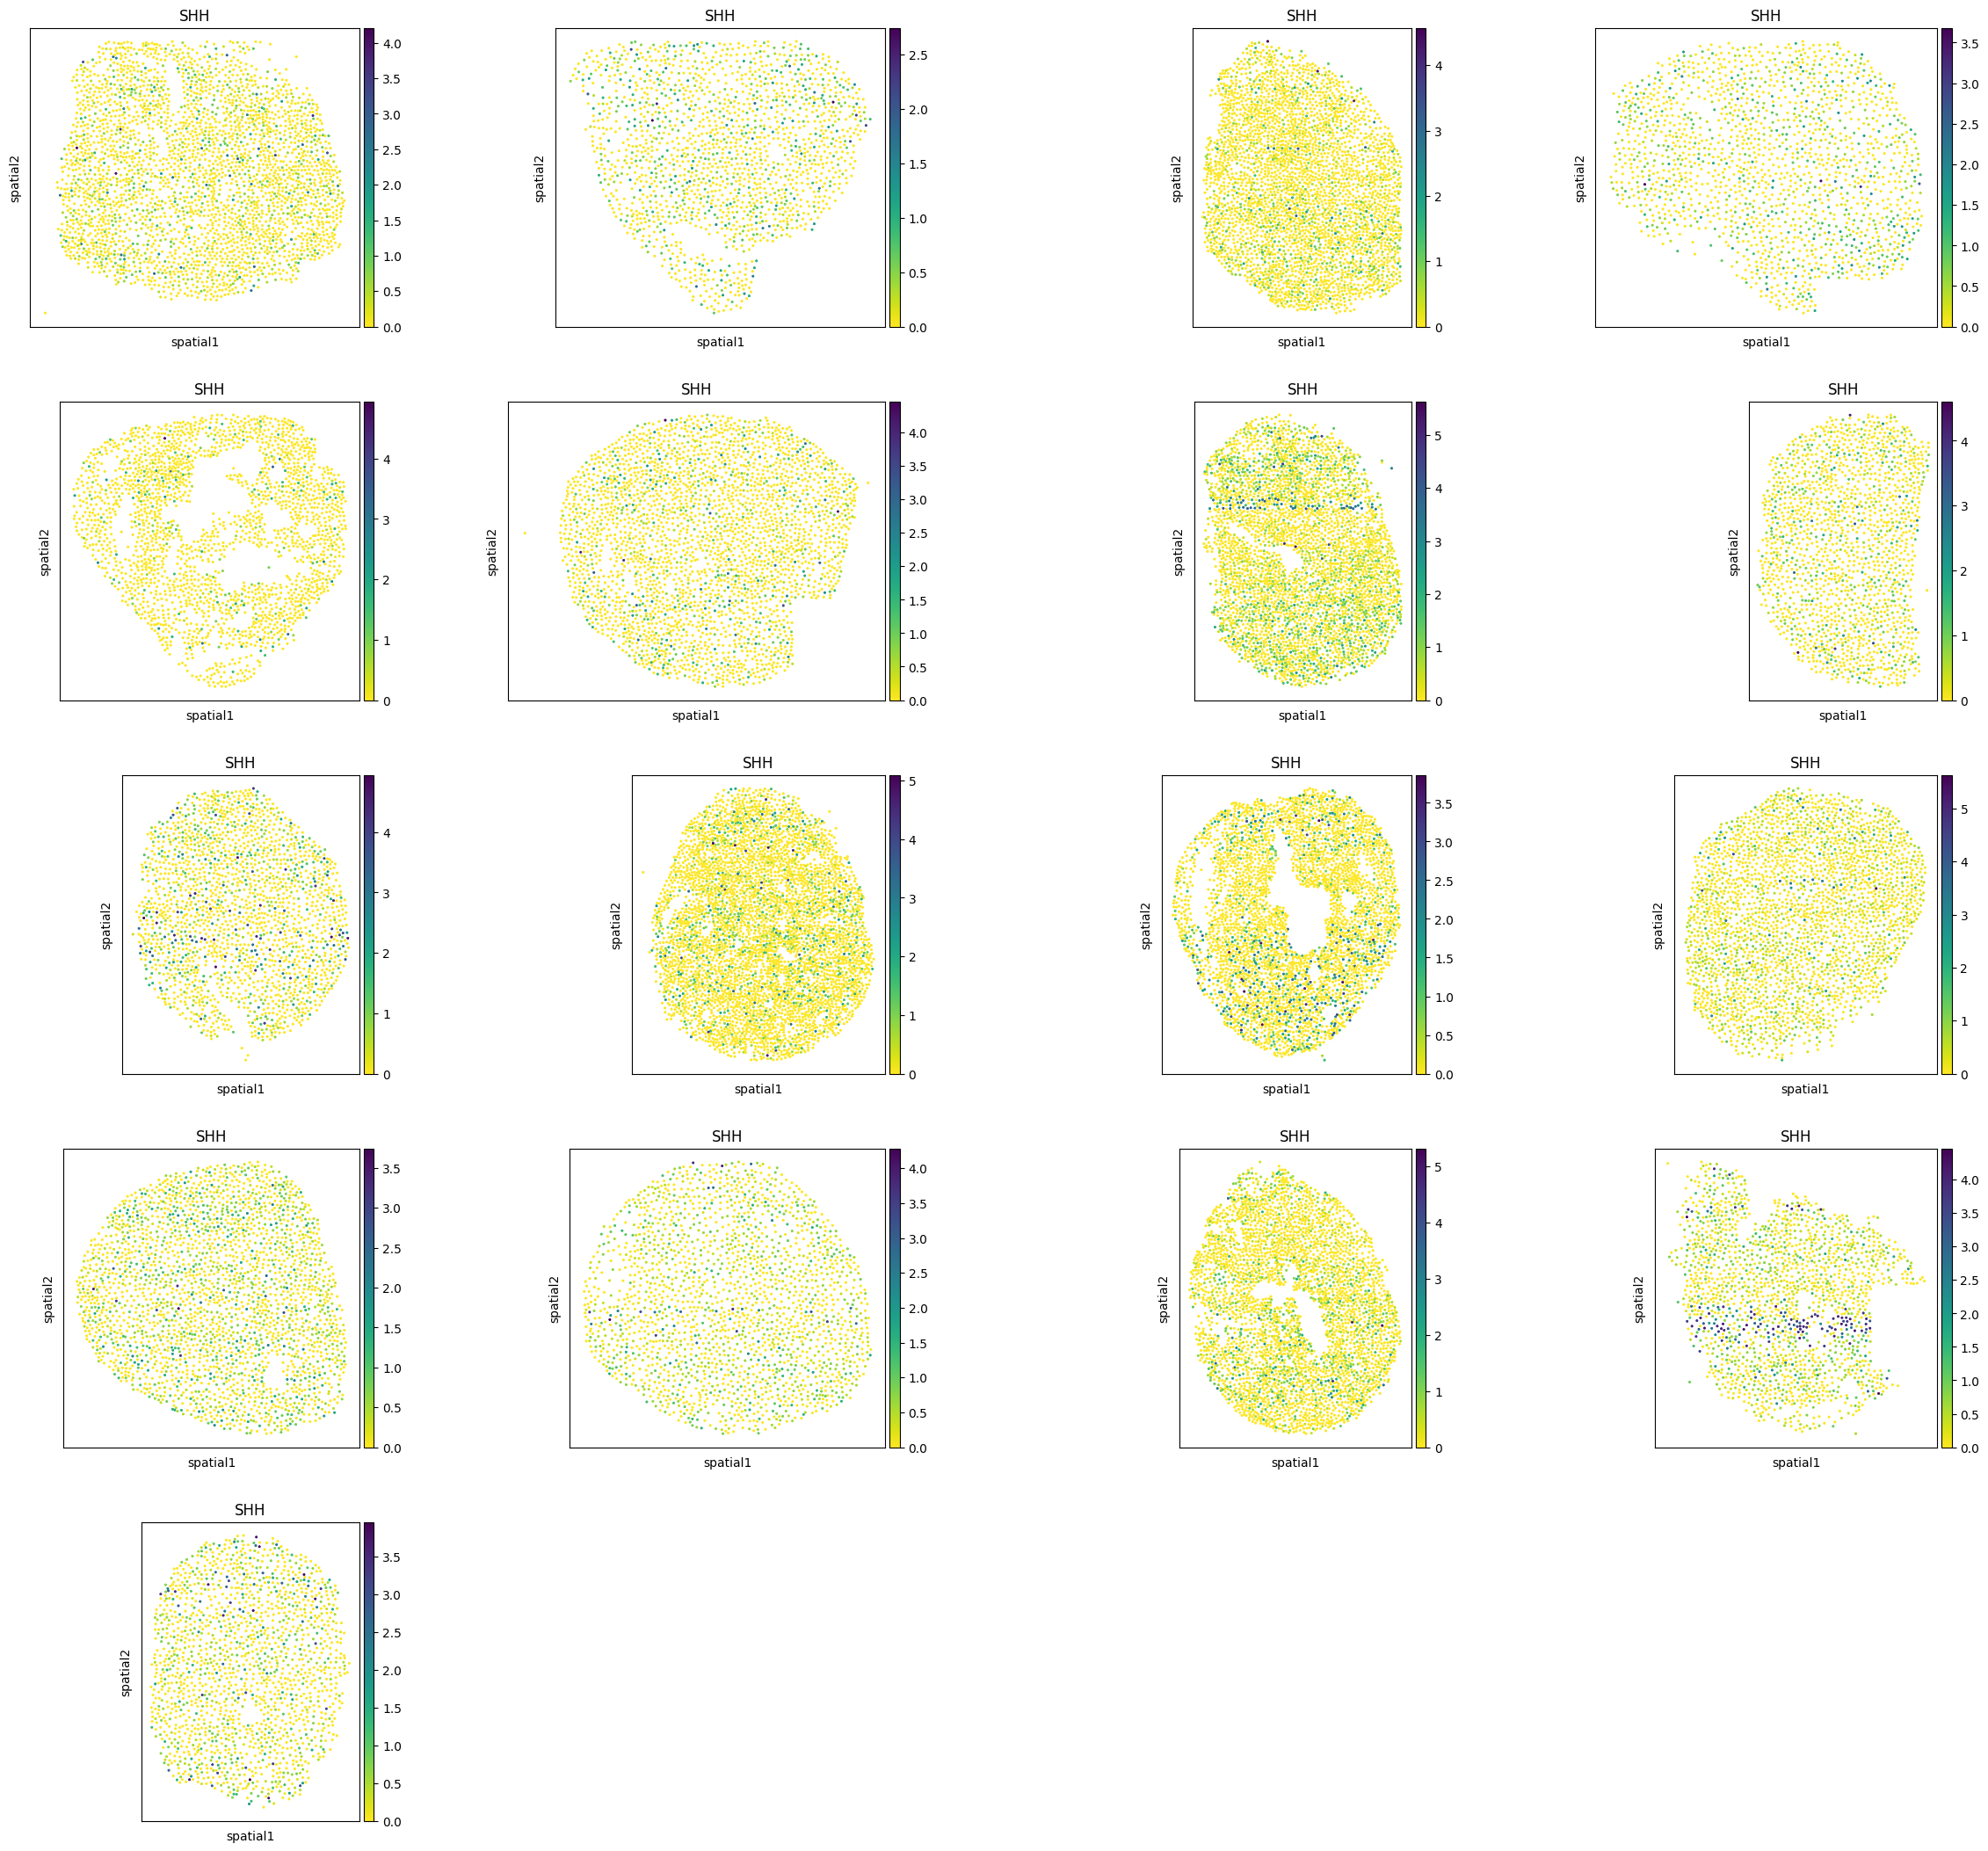

In [62]:
layer_var = 'log1p_norm'
adata.X = adata.layers[layer_var]
sq.pl.spatial_scatter(
    adata,
    library_key = 'sample',
    #library_id = ['slide1_A2-1', 'slide4_B2-2'],
    color =  ['SHH'],
    shape= None,
    size = 4, 
    cmap = 'viridis_r',
    save = f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/legnini23_{layer_var}.jpeg'
)

In [17]:
gex_shh = adata[:, 'SHH'].X

shh_threshold = 0.7 works well for sample = 'slide1_A2-1'

In [39]:
# Identify SHH center
shh_threshold = 3.7

shh_values = adata[:, 'SHH'].X
# If sparse, convert to dense
if issparse(shh_values):
    shh_values = shh_values.toarray()
# Ensure it's a 1D array
shh_values = shh_values.flatten()

adata.obs['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


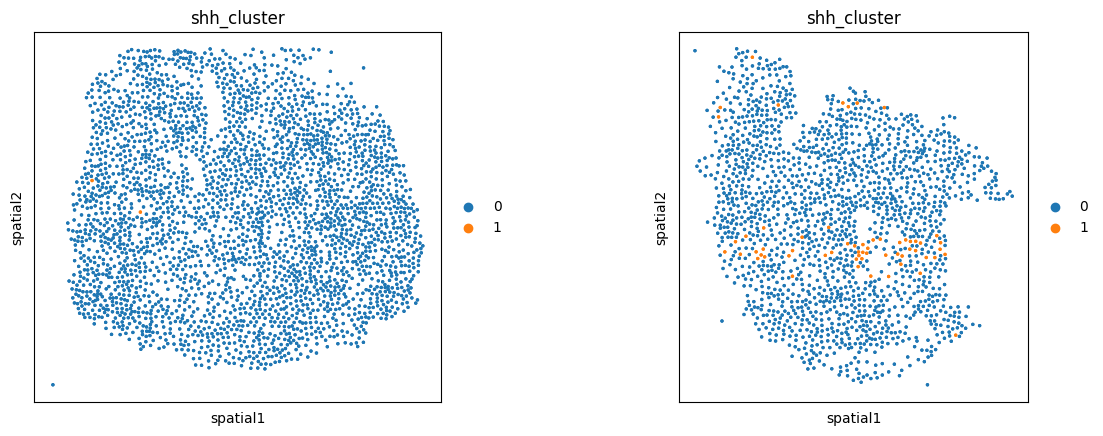

In [40]:
sq.pl.spatial_scatter(
    adata,
    library_key = 'sample',
    library_id = ['slide1_A2-1', 'slide4_B2-2'],
    color =  ['shh_cluster'],
    shape= None,
    size = 8, 
)

In [43]:
sub_adata = adata[adata.obs['sample'].isin(['slide1_A2-1', 'slide4_B2-2'])]

In [85]:
np.unique(sub_adata.obs["shh_cluster"])

array(['0', '1'], dtype=object)

In [20]:
sq.tl.var_by_distance(
    adata=sub_adata,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/tl/_var_by_distance.py:65: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[design_matrix_key] = _add_metadata(


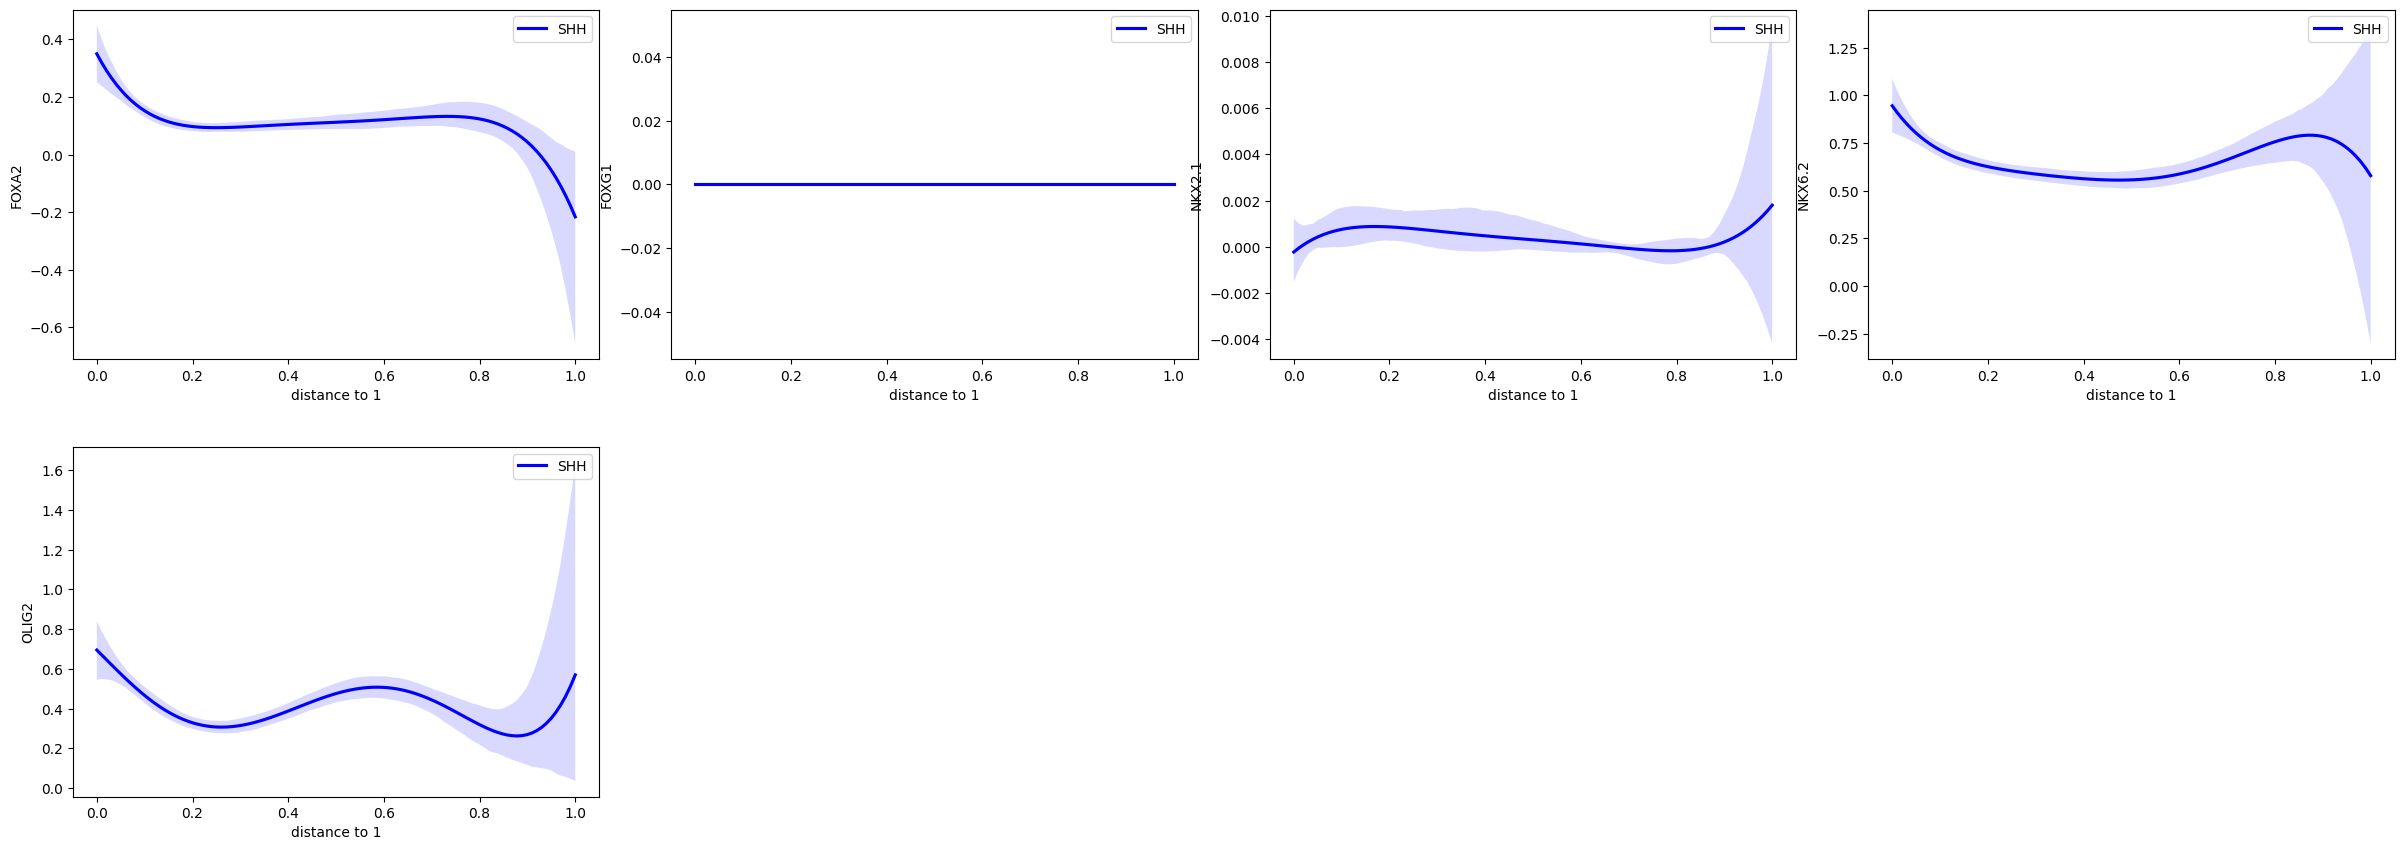

In [21]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=pathway_genes,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

In [42]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=downregulated_genes,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

NameError: name 'sub_adata' is not defined

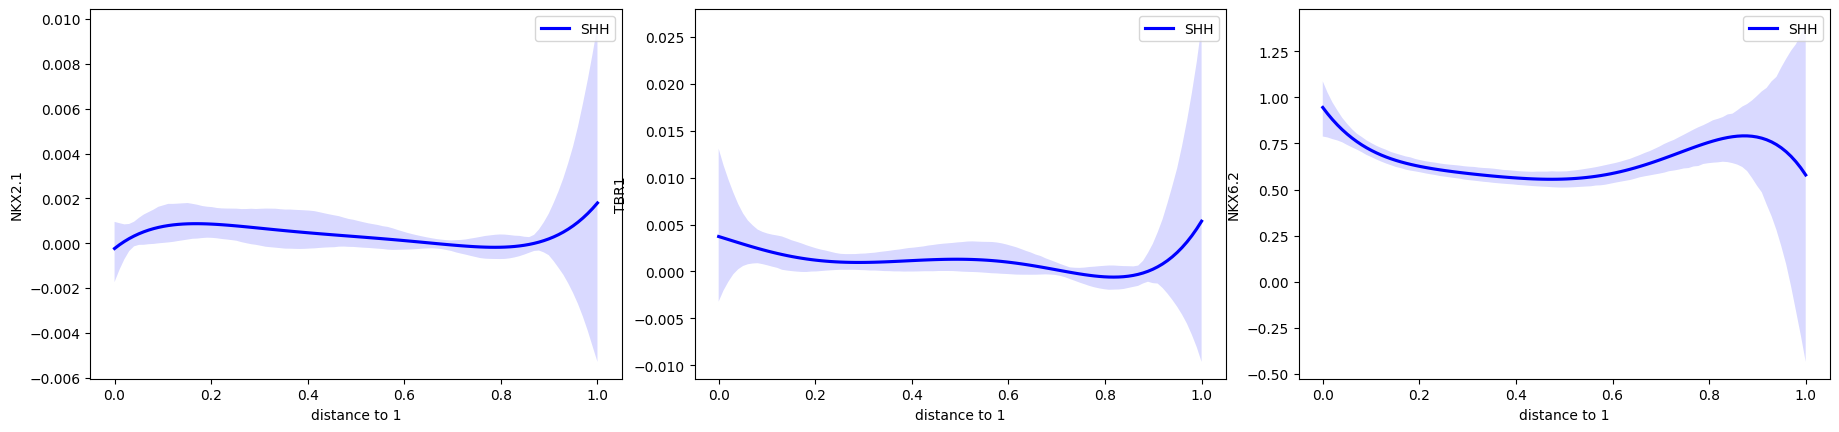

In [45]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=['NKX2.1', 'TBR1', 'NKX6.2'],
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

In [51]:
global_embedding = ['NKX2.1', 'TBR1', 'NKX6.2', 'OLIG1', 'EYA4']
local_embedding = ['KLF13', 'CUX2', 'ARG1', 'SATB2', 'MNX1']

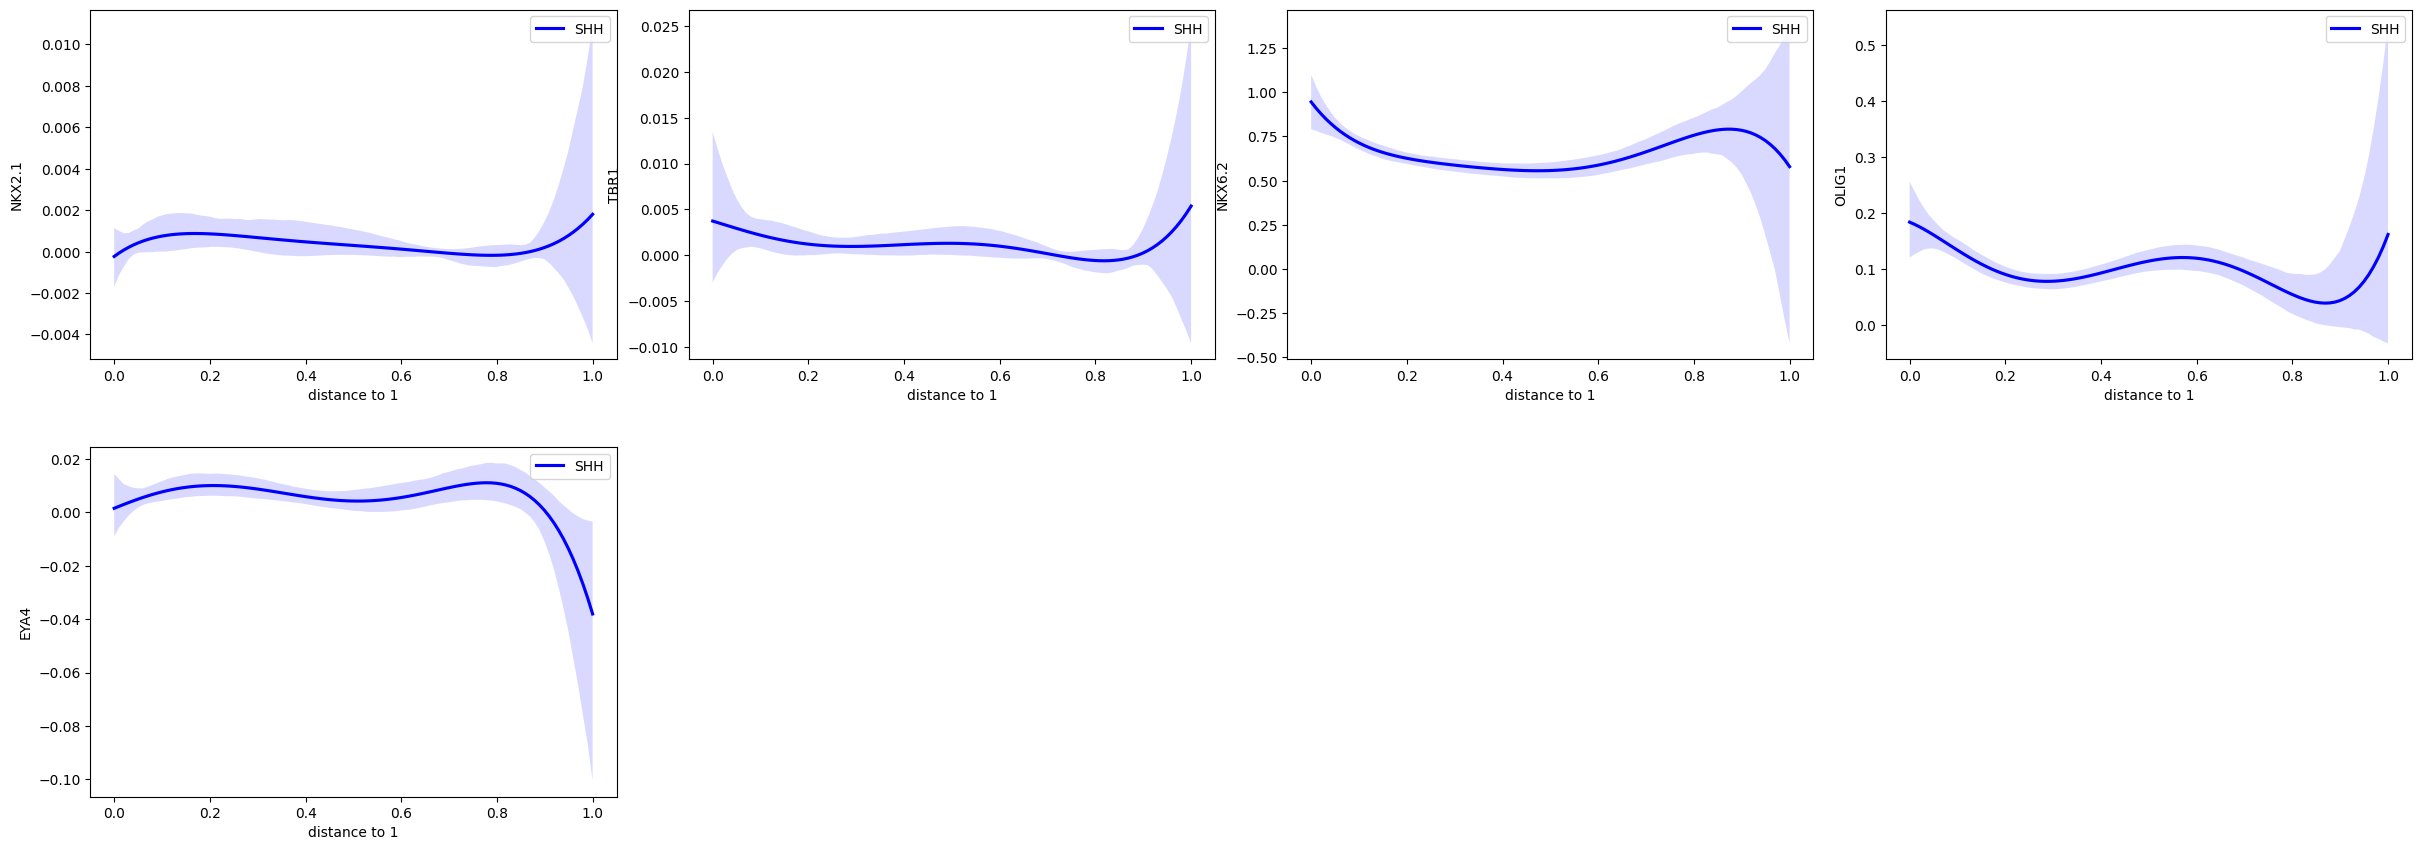

In [52]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=global_embedding,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

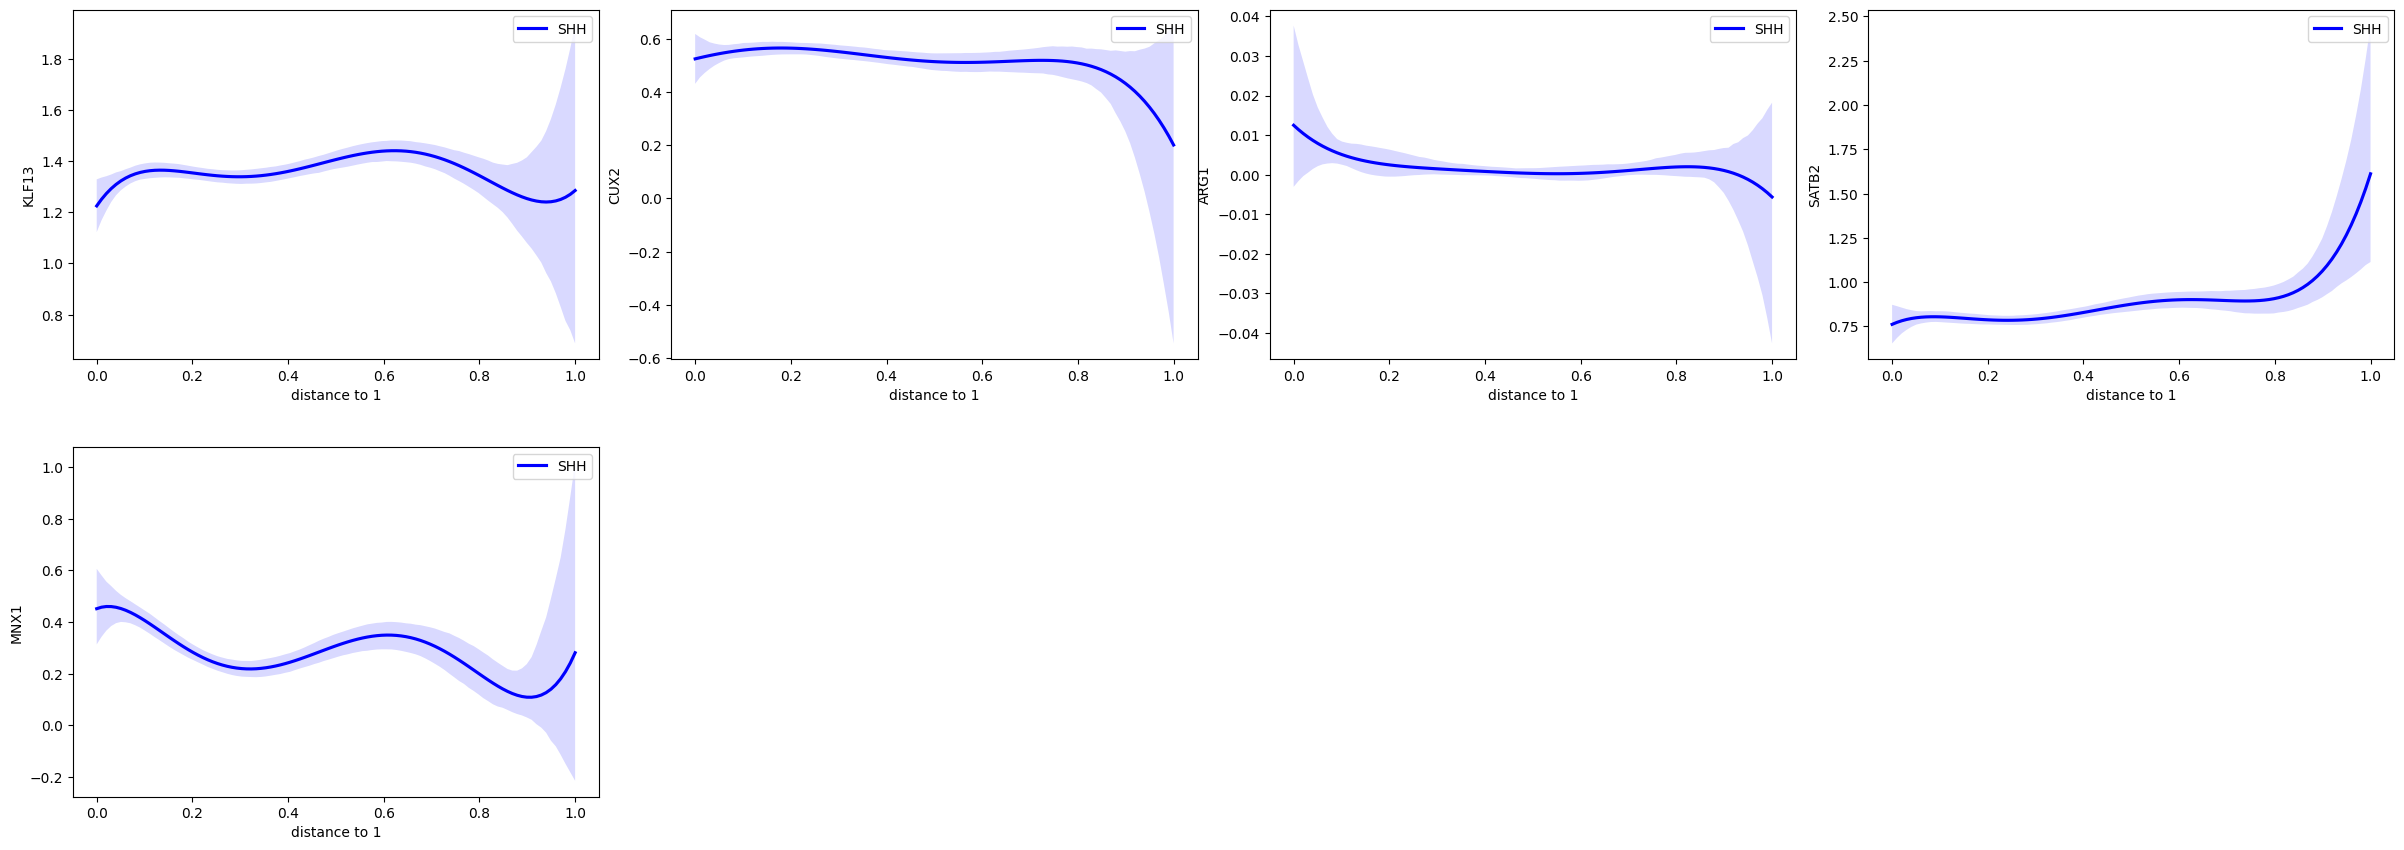

In [53]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=local_embedding,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)